# CQT Fakeprint: Real vs Theoretical Speed up / Pitch Shift

Compares pipeline CQT fakeprints:
- **Speed up** (vinyl-style, like `sox file.mp3 out.wav speed 1.02`): real = time-domain speed on audio; artificial = shift CQT in frequency.
- **Pitch shift**: real = torchaudio PitchShift on audio; artificial = shift CQT in frequency (same logic).

In [1]:
import os
import sys
import numpy as np
import torch
import torchaudio
import soxr
import matplotlib.pyplot as plt
import scipy.interpolate as interp

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
os.chdir(project_root)
sys.path.insert(0, project_root)

from nnAudio.features import CQT
from src.models.utils import get_spectrum, get_freqs, get_fakeprints

## Params (pipeline defaults)

In [92]:
N_FFT = 16384
SR = 48000
BINS_PER_OCTAVE = 96
FREQ_RANGE = [200, 6000]
F_MIN = 32.7
DB_RANGE = [-80, 5]

# Speed up (vinyl-style, like sox file.mp3 out.wav speed 1.02): same SR, shorter duration, pitch × factor
SPEED_FACTOR = 1.1
# Pitch shift: semitones (e.g. +2)
PITCH_SEMITONES = 2.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Helpers: CQT transform + fakeprint from waveform

In [93]:
def make_cqt_transform(sr, n_fft=N_FFT, f_min=F_MIN, bins_per_octave=BINS_PER_OCTAVE):
    hop_length = n_fft // 2
    nyquist = sr / 2
    n_octaves = np.log2(nyquist / f_min) - 0.1
    nbins = int(n_octaves * bins_per_octave)
    return CQT(
        sr=sr,
        hop_length=hop_length,
        fmin=f_min,
        n_bins=nbins,
        bins_per_octave=bins_per_octave,
        output_format="Magnitude",
        verbose=False,
    ).to(device)


def cqt_fakeprint_from_waveform(waveform, sr, cqt_transform, freqs, mask, db_range=DB_RANGE):
    """CQT -> dB -> mean(time) -> crop -> get_fakeprints (pipeline)."""
    waveform = waveform.mean(dim=0, keepdim=True).to(device)
    spec = get_spectrum(cqt_transform, waveform)
    spec = spec.mean(dim=-1).squeeze(0)
    spec_crop = spec[mask]
    return get_fakeprints(spec_crop, freqs, db_range=db_range)


def speed_up_waveform(waveform, speed):
    """Like SoX 'speed 1.02': shorter duration, pitch × speed. Same SR. waveform: (C, T)."""
    w = waveform.cpu().numpy()
    if w.ndim == 1:
        w = w[None, :]
    C, N = w.shape
    new_len = int(N / speed)
    indices_new = np.arange(new_len, dtype=np.float64) * speed
    out = np.stack([np.interp(indices_new, np.arange(N), w[c]) for c in range(C)])
    return torch.from_numpy(out).to(waveform.dtype).to(waveform.device)

## Load audio

In [94]:
import random
from tabnanny import verbose

audio_path = os.path.join(project_root, "data/ai/fffbcac54e3205844118ef7324c21e6db87fe041857efb723e04dd525ed65ef0.mp3")

# Get the duration of the audio
info = torchaudio.info(audio_path)
total_secs = info.num_frames / info.sample_rate
segment_secs = 30

if total_secs <= segment_secs:
    # Audio is shorter than 30 seconds, load entire file
    offset = 0
    num_frames = -1
else:
    # Pick a random start for a 30 second window
    max_offset_sec = total_secs - segment_secs
    offset_sec = random.uniform(0, max_offset_sec)
    offset = int(offset_sec * info.sample_rate)
    num_frames = int(segment_secs * info.sample_rate)

waveform, sr = torchaudio.load(audio_path, frame_offset=offset, num_frames=num_frames, channels_first=True)
if sr != SR:
    waveform = torch.from_numpy(soxr.resample(waveform.T.numpy(), sr, SR)).T.to(waveform.dtype)
    sr = SR
waveform = waveform.to(device)
print(f"Shape {waveform.shape}, sr={sr}, offset={offset/sr:.2f}s, duration={waveform.shape[-1]/sr:.2f}s")

Shape torch.Size([2, 1440000]), sr=48000, offset=157.00s, duration=30.00s


## Reference CQT fakeprint (original SR)

In [95]:
cqt_ref = make_cqt_transform(SR)
freqs_ref, mask_ref = get_freqs(N_FFT, SR, transform="cqt", bins_per_octave=BINS_PER_OCTAVE, freq_range=FREQ_RANGE, f_min=F_MIN)
freqs_ref = freqs_ref.to(device)

# Reference CQT spectrum (dB, mean time) and fakeprint
with torch.no_grad():
    spec_ref = get_spectrum(cqt_ref, waveform.mean(dim=0, keepdim=True))
spec_ref = spec_ref.mean(dim=-1).squeeze(0)[mask_ref].cpu().numpy()
fp_ref = cqt_fakeprint_from_waveform(waveform, SR, cqt_ref, freqs_ref, mask_ref)
fp_ref = fp_ref.cpu().numpy()
freqs_ref_np = freqs_ref.cpu().numpy()
print(f"Reference: CQT shape {spec_ref.shape}, fakeprint length {len(fp_ref)}")

Reference: CQT shape (471,), fakeprint length 471


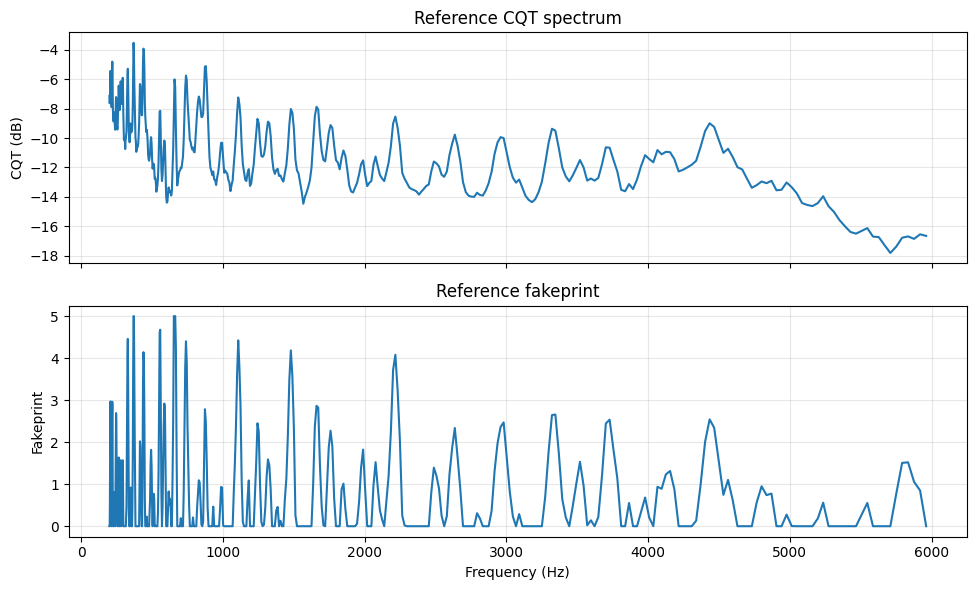

In [96]:
# Reference: CQT spectrum and fakeprint
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(freqs_ref_np, spec_ref, color="C0")
axes[0].set_ylabel("CQT (dB)")
axes[0].set_title("Reference CQT spectrum")
axes[0].grid(True, alpha=0.3)
axes[1].plot(freqs_ref_np, fp_ref, color="C0")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Fakeprint")
axes[1].set_title("Reference fakeprint")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1. Speed up (vinyl-style): Real vs Artificial

Like `sox file.mp3 out.wav speed 1.02`: play faster → shorter duration, pitch × factor.

- **Real**: apply `speed_up_waveform(waveform, SPEED_FACTOR)` (time-domain resample), then CQT + fakeprint at same SR.
- **Artificial**: theoretical shift on CQT: content at f moves to f × speed, so value at f = ref spectrum at f / speed (interpolate).

In [97]:
# Real: speed up audio (vinyl-style), same SR -> CQT + fakeprint
wave_speed = speed_up_waveform(waveform, SPEED_FACTOR)
with torch.no_grad():
    spec_speed_real = get_spectrum(cqt_ref, wave_speed.mean(dim=0, keepdim=True)).mean(dim=-1).squeeze(0)[mask_ref].cpu().numpy()
fp_speed_real = cqt_fakeprint_from_waveform(wave_speed, SR, cqt_ref, freqs_ref, mask_ref)
fp_speed_real = fp_speed_real.cpu().numpy()

# Artificial: theoretical shift on CQT — value at f = ref(f/speed)
freqs_shifted = freqs_ref_np / SPEED_FACTOR
interp_ref = interp.interp1d(freqs_ref_np, spec_ref, kind="linear", bounds_error=False, fill_value=(spec_ref.min(), spec_ref.max()))
spec_speed_art = interp_ref(freqs_shifted)
spec_shifted = torch.from_numpy(spec_speed_art).float().to(device)
fp_speed_art = get_fakeprints(spec_shifted, freqs_ref, db_range=DB_RANGE).cpu().numpy()

print(f"Speed {SPEED_FACTOR}: ref duration {waveform.shape[-1]/SR:.2f}s -> sped {wave_speed.shape[-1]/SR:.2f}s")

Speed 1.1: ref duration 30.00s -> sped 27.27s


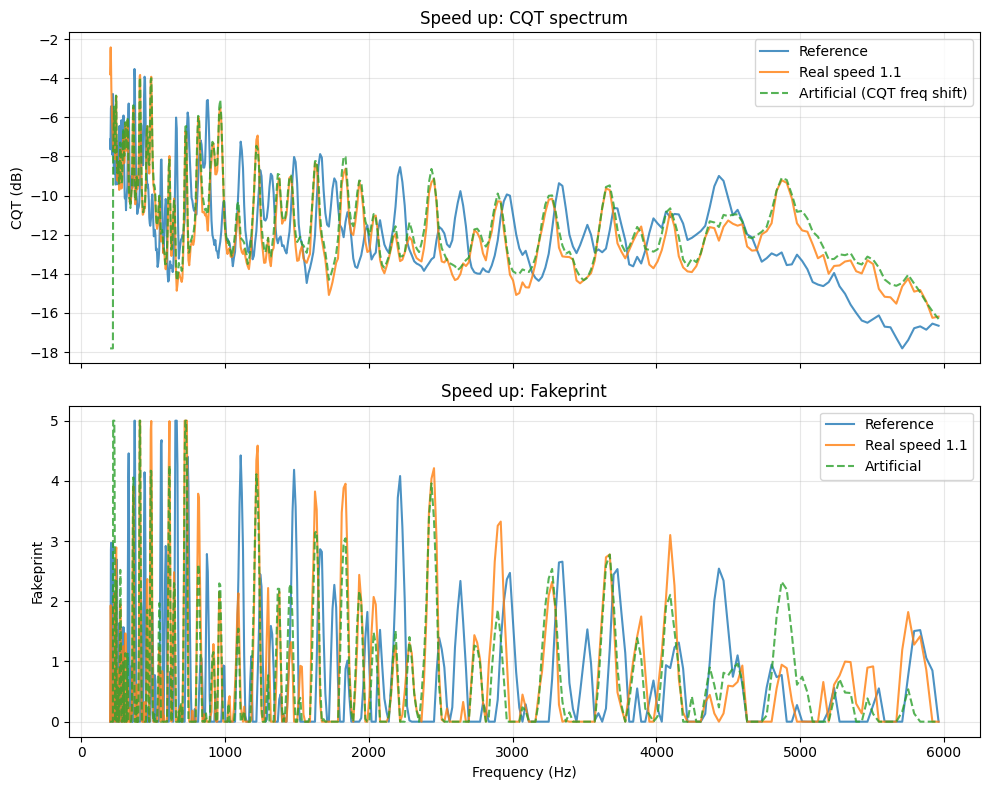

In [98]:
# Speed up: CQT and fakeprint comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(freqs_ref_np, spec_ref, label="Reference", alpha=0.8)
axes[0].plot(freqs_ref_np, spec_speed_real, label=f"Real speed {SPEED_FACTOR}", alpha=0.8)
axes[0].plot(freqs_ref_np, spec_speed_art, label="Artificial (CQT freq shift)", alpha=0.8, linestyle="--")
axes[0].set_ylabel("CQT (dB)")
axes[0].set_title("Speed up: CQT spectrum")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_speed_real, label=f"Real speed {SPEED_FACTOR}", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_speed_art, label="Artificial", alpha=0.8, linestyle="--")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Fakeprint")
axes[1].set_title("Speed up: Fakeprint")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

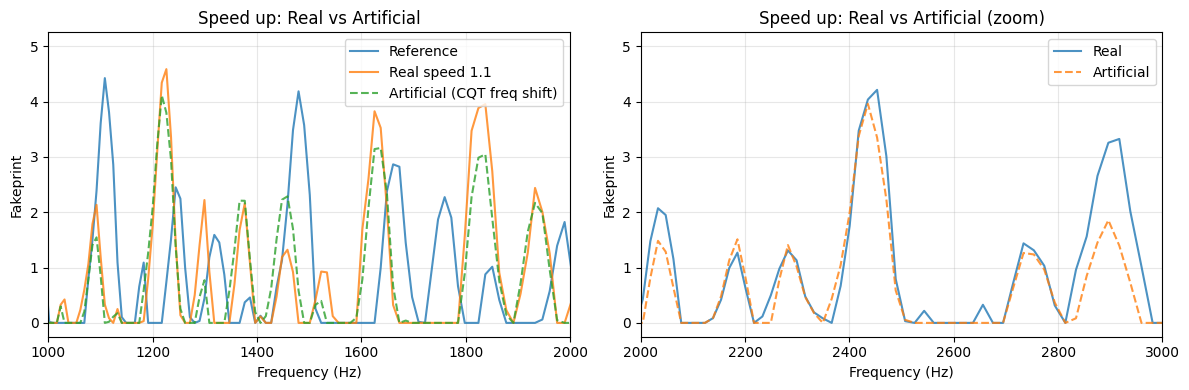

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.8)
ax.plot(freqs_ref_np, fp_speed_real, label=f"Real speed {SPEED_FACTOR}", alpha=0.8)
ax.plot(freqs_ref_np, fp_speed_art, label="Artificial (CQT freq shift)", alpha=0.8, linestyle="--")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Fakeprint")
ax.set_title("Speed up: Real vs Artificial")
ax.set_xlim(1000, 2000)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(freqs_ref_np, fp_speed_real, label="Real", alpha=0.8)
ax.plot(freqs_ref_np, fp_speed_art, label="Artificial", alpha=0.8, linestyle="--")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Fakeprint")
ax.set_title("Speed up: Real vs Artificial (zoom)")
ax.set_xlim(2000, 3000)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Pitch shift: Real vs Artificial

- **Real**: pitch shift audio by `PITCH_SEMITONES` semitones, then CQT + fakeprint.
- **Artificial**: theoretical shift in frequency: content at f moves to f × 2^(n/12). So new spectrum at f_new = ref spectrum at f_new / 2^(n/12) (interpolate on CQT).

In [101]:
ratio = 2.0 ** (PITCH_SEMITONES / 12.0)

# Real: pitch shift on audio
pitch_shifter = torchaudio.transforms.PitchShift(sample_rate=SR, n_steps=PITCH_SEMITONES).to(device)
wave_ps = pitch_shifter(waveform)
with torch.no_grad():
    spec_ps_real = get_spectrum(cqt_ref, wave_ps.mean(dim=0, keepdim=True)).mean(dim=-1).squeeze(0)[mask_ref].cpu().numpy()
fp_ps_real = cqt_fakeprint_from_waveform(wave_ps, SR, cqt_ref, freqs_ref, mask_ref)
fp_ps_real = fp_ps_real.cpu().numpy()

# Artificial: shift CQT in freq: value at f_new = ref(f_new / ratio)
freqs_shifted = freqs_ref_np / ratio
interp_ref = interp.interp1d(freqs_ref_np, spec_ref, kind="linear", bounds_error=False, fill_value=(spec_ref.min(), spec_ref.max()))
spec_ps_art = interp_ref(freqs_shifted)
spec_shifted = torch.from_numpy(spec_ps_art).float().to(device)
fp_ps_art = get_fakeprints(spec_shifted, freqs_ref, db_range=DB_RANGE).cpu().numpy()

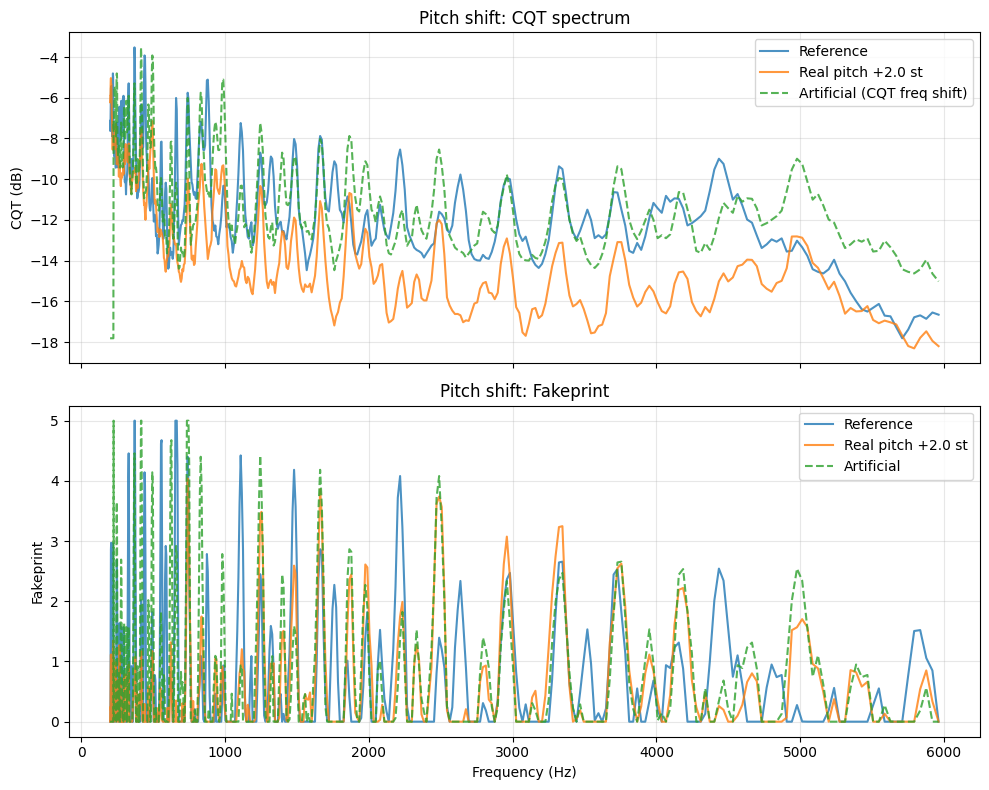

In [102]:
# Pitch shift: CQT and fakeprint comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(freqs_ref_np, spec_ref, label="Reference", alpha=0.8)
axes[0].plot(freqs_ref_np, spec_ps_real, label=f"Real pitch {PITCH_SEMITONES:+.1f} st", alpha=0.8)
axes[0].plot(freqs_ref_np, spec_ps_art, label="Artificial (CQT freq shift)", alpha=0.8, linestyle="--")
axes[0].set_ylabel("CQT (dB)")
axes[0].set_title("Pitch shift: CQT spectrum")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_ps_real, label=f"Real pitch {PITCH_SEMITONES:+.1f} st", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_ps_art, label="Artificial", alpha=0.8, linestyle="--")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Fakeprint")
axes[1].set_title("Pitch shift: Fakeprint")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary: same axes (reference freq grid)

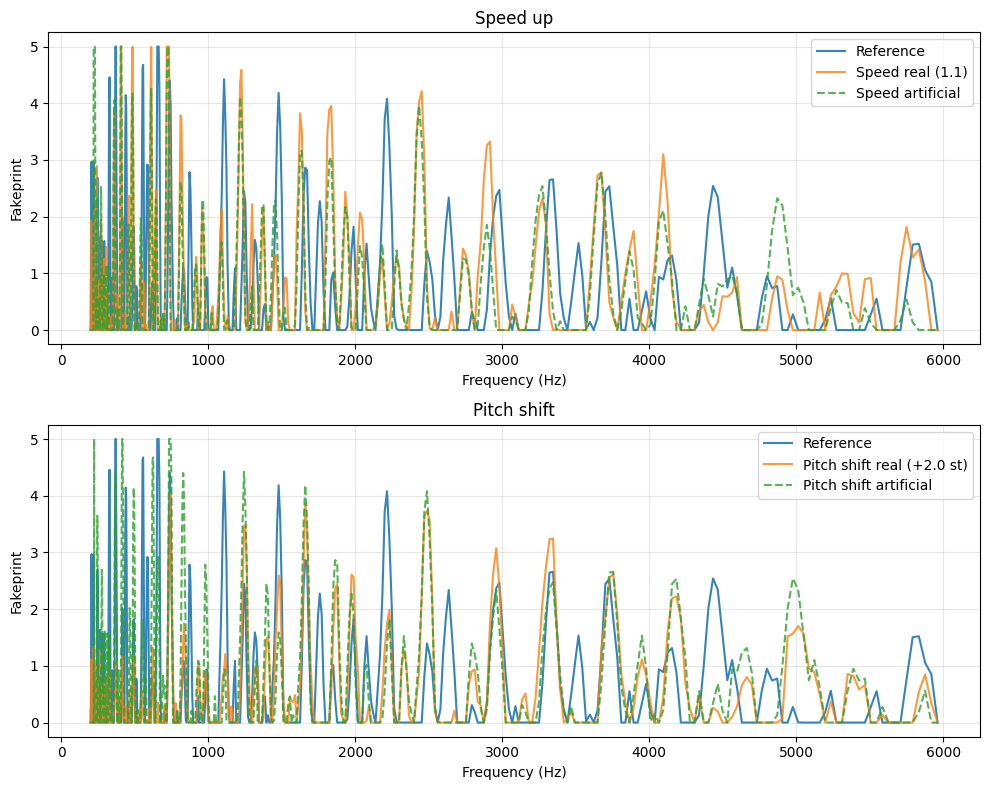

In [103]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.9)
axes[0].plot(freqs_ref_np, fp_speed_real, label=f"Speed real ({SPEED_FACTOR})", alpha=0.8)
axes[0].plot(freqs_ref_np, fp_speed_art, label="Speed artificial", linestyle="--", alpha=0.8)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Fakeprint")
axes[0].set_title("Speed up")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.9)
axes[1].plot(freqs_ref_np, fp_ps_real, label=f"Pitch shift real ({PITCH_SEMITONES:+.1f} st)", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_ps_art, label="Pitch shift artificial", linestyle="--", alpha=0.8)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Fakeprint")
axes[1].set_title("Pitch shift")
ax
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()